Costruzione del circuito Random Clifford

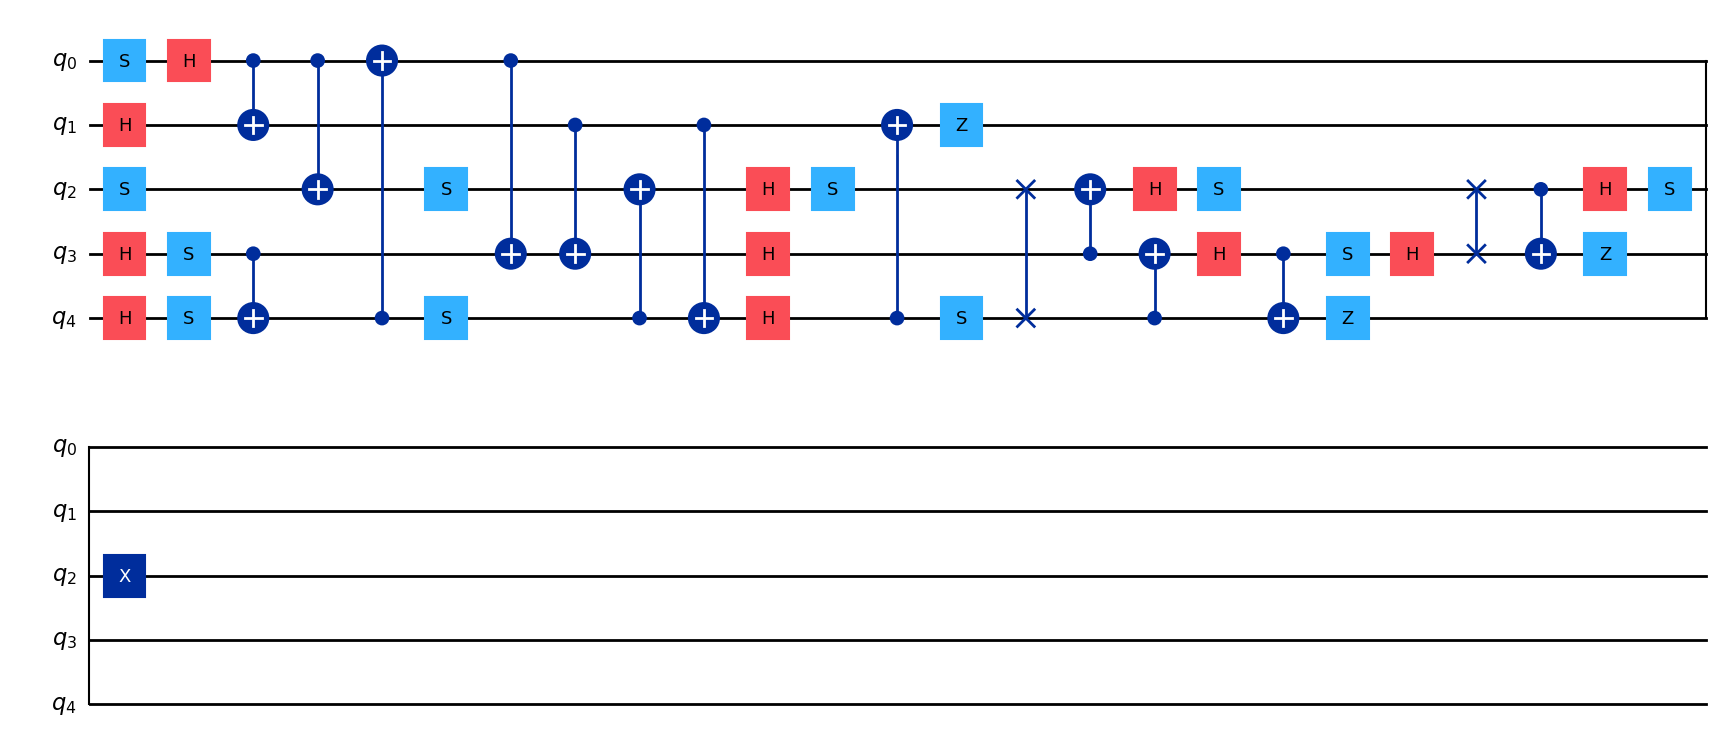

In [2]:
from qiskit.quantum_info import random_clifford
from qiskit import transpile

# Crea il circuito con n qubit
n=5
clifford = random_clifford(n)

qc = clifford.to_circuit()

# Disegna il circuito
qc.draw("mpl")

Costruisco il simulatore partendo dalla backend fisica backend_kingston

In [3]:
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit_aer.noise import NoiseModel

# Simuleremo il nostro circuito utilizzando come riferimento IBM_kingston
service = QiskitRuntimeService()
backend_kingston = service.backend('ibm_kingston')
noise_model = NoiseModel.from_backend(backend_kingston)
# Simulatore con modello del rumore preso da IBM_kingston
noise_kingston_sim = AerSimulator(noise_model=noise_model)

qiskit_runtime_service.__init__:WARNING:2026-04-02 17:04:33,543: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-02 17:04:33,545: Using instance: open-instance, plan: open


Differenza nei gate utilizzati per i 4 transpile

In [4]:
qc_transpiled_0 = transpile(qc, backend_kingston, optimization_level=0)
qc_transpiled_1 = transpile(qc, backend_kingston, optimization_level=1)
qc_transpiled_2 = transpile(qc, backend_kingston, optimization_level=2)
qc_transpiled_3 = transpile(qc, backend_kingston, optimization_level=3)
print("\nDifferenza nei gate usati:")
print("optimization_level=0",qc_transpiled_0.count_ops())
print("optimization_level=1",qc_transpiled_1.count_ops())
print("optimization_level=1",qc_transpiled_2.count_ops())
print("optimization_level=3",qc_transpiled_3.count_ops())


Differenza nei gate usati:
optimization_level=0 OrderedDict({'sx': 103, 'rz': 88, 'cz': 46, 'x': 1})
optimization_level=1 OrderedDict({'sx': 59, 'rz': 47, 'cz': 34})
optimization_level=1 OrderedDict({'sx': 43, 'rz': 29, 'cz': 21, 'x': 1})
optimization_level=3 OrderedDict({'sx': 39, 'rz': 24, 'cz': 20})


Ricavo il rumore del QC in base ai 4 livelli di ottimizzazione e lo confronto con lo stato ideale

In [5]:
from qiskit import transpile
from qiskit.quantum_info import DensityMatrix, state_fidelity

# Copio il circuito e salvo la matrice di densità
qc_noise=qc.copy()
ρ_ideal = DensityMatrix(qc_noise)
qc_noise.save_density_matrix()

# Transpilo e simulo il circuito con optimization_level=0 ottenendo la matrice di densità
qc_level_0 = transpile(qc_noise, noise_kingston_sim, optimization_level=0)
ρ_real_level_0 = noise_kingston_sim.run(qc_level_0).result().data()['density_matrix']
# Comparazione tra la matrice di densità ideale e quella con optimization_level=0
fielity_level_0 = state_fidelity(ρ_ideal, ρ_real_level_0)

# Transpilo e simulo il circuito con optimization_level=1 ottenendo la matrice di densità
qc_level_1 = transpile(qc_noise, noise_kingston_sim, optimization_level=1)
ρ_real_level_1 = noise_kingston_sim.run(qc_level_1).result().data()['density_matrix']
# Comparazione tra la matrice di densità ideale e quella con optimization_level=1
fielity_level_1 = state_fidelity(ρ_ideal, ρ_real_level_1)

# Transpilo e simulo il circuito con optimization_level=2 ottenendo la matrice di densità
qc_level_2 = transpile(qc_noise, noise_kingston_sim, optimization_level=2)
ρ_real_level_2 = noise_kingston_sim.run(qc_level_2).result().data()['density_matrix']
# Comparazione tra la matrice di densità ideale e quella con optimization_level=2
fielity_level_2 = state_fidelity(ρ_ideal, ρ_real_level_2)

# Transpilo e simulo il circuito con optimization_level=3 ottenendo la matrice di densità
qc_level_3 = transpile(qc_noise, noise_kingston_sim, optimization_level=3)
ρ_real_level_3 = noise_kingston_sim.run(qc_level_3).result().data()['density_matrix']
# Comparazione tra la matrice di densità ideale e quella con optimization_level=3
fielity_level_3 = state_fidelity(ρ_ideal, ρ_real_level_3)

print(f"Fidelity tra stato ideale e rumoroso: {fielity_level_0:.4f}")
print(f"Fidelity tra stato ideale e rumoroso: {fielity_level_1:.4f}")
print(f"Fidelity tra stato ideale e rumoroso: {fielity_level_2:.4f}")
print(f"Fidelity tra stato ideale e rumoroso: {fielity_level_3:.4f}")

Fidelity tra stato ideale e rumoroso: 0.9706
Fidelity tra stato ideale e rumoroso: 0.9750
Fidelity tra stato ideale e rumoroso: 0.9828
Fidelity tra stato ideale e rumoroso: 0.9828


Confronto tra valori desiderati in base ai diversi gradi di Optimization_Level (più vicino a 1 e più è fedele a quello ideale)

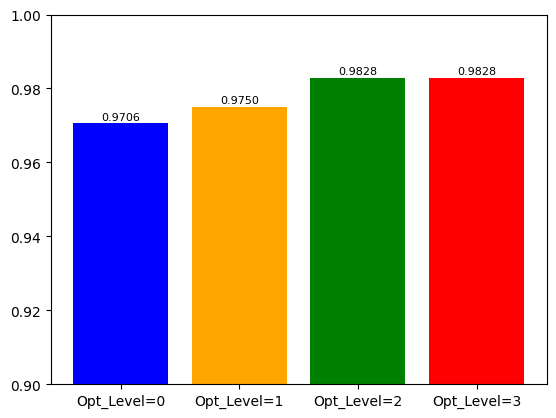

In [7]:
import matplotlib.pyplot as plt

data = [fielity_level_0,fielity_level_1,fielity_level_2, fielity_level_3]
labels = ["Opt_Level=0", "Opt_Level=1","Opt_Level=2", "Opt_Level=3"]
plt.ylim(0.9, 1)
plt.bar(labels, data, color=['blue', 'orange', 'green', 'red'])
for i, v in enumerate(data):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center', fontsize=8)

Profondità del QC e #Gates in base ai 4 livelli di ottimizzazione di Qiskit

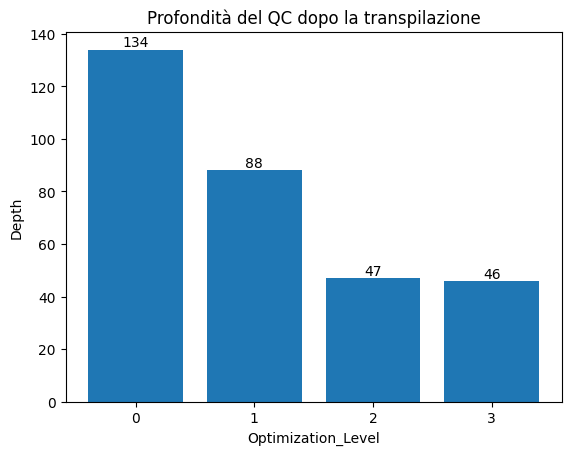

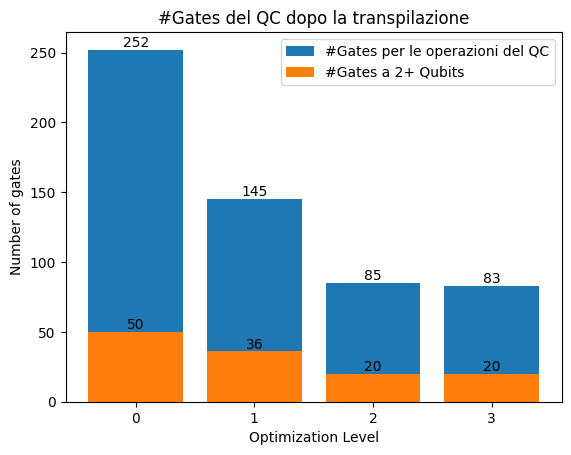

In [ ]:
import matplotlib.pyplot as plt

depths = [0,0,0,0]
gate_counts = [0,0,0,0]
non_local_gate_counts = [0,0,0,0]
levels = ["0", "1", "2", "3"]

# Eseguo la traspilazione sempre basata su ibm_kingston e raccolgo la profondità e #Gates per ogni optimization_level facendo una media su 10 transpilazioni
for i in range(10):
    for level in range(4):
        circ = transpile(qc, backend_kingston, optimization_level=level)
        depths[level] += circ.depth()
        gate_counts[level] += sum(circ.count_ops().values())
        non_local_gate_counts[level] += circ.num_nonlocal_gates()
        
for i in range(4):
    depths[i] = round(depths[i]/10)
    gate_counts[i] = round(gate_counts[i]/10)
    non_local_gate_counts[i] = round(non_local_gate_counts[i]/10)

# Grafico per la Profondità
plt.figure()
bars = plt.bar(levels, depths, label='Depth')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom', fontsize=10)
plt.xlabel("Optimization_Level")
plt.ylabel("Depth")
plt.title("Profondità del QC dopo la transpilazione")
plt.show()
# Grafico per il #Gates
plt.figure()
bars = plt.bar(levels, gate_counts, label='#Gates per le operazioni del QC')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom', fontsize=10)
bars = plt.bar(levels, non_local_gate_counts, label='#Gates a 2+ Qubits ')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom', fontsize=10)
plt.xlabel("Optimization Level")
plt.ylabel("Number of gates")
plt.legend()
plt.title("#Gates del QC dopo la transpilazione")
plt.show()

Confronto dei tempi di esecuzione in base ai diversi 'Optimization_Level' sfruttando 'scheduled_circuit' prendendo come riferimento sempre ibm_kingston

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

exec_times = [0,0,0,0]

# Eseguo 100 schedulazioni per ogni 'optimization_level' e prenderò la media di esecuzione

for l in range(4):
  for i in range(100):
    scheduled_circuit = transpile(qc, backend=backend_kingston, optimization_level=l, scheduling_method="alap")
    circuit_duration = scheduled_circuit.duration * backend_kingston.configuration().dt
    exec_times[l] += circuit_duration*1000*1000*1000

print("Tempo di esecuzione con 'optimization_level=0'  {:}[ns]".format(exec_times[0]/100))
print("Tempo di esecuzione con 'optimization_level=1'  {:}[ns]".format(exec_times[1]/100))
print("Tempo di esecuzione con 'optimization_level=2'  {:}[ns]".format(exec_times[2]/100))
print("Tempo di esecuzione con 'optimization_level=3'  {:}[ns]".format(exec_times[3]/100))



Tempo di esecuzione con 'optimization_level=0'  4188.72[ns]
Tempo di esecuzione con 'optimization_level=1'  3241.08[ns]
Tempo di esecuzione con 'optimization_level=2'  1783.76[ns]
Tempo di esecuzione con 'optimization_level=3'  1780.8[ns]
